In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import io

warnings.filterwarnings('ignore')
sns.set_theme(style = 'darkgrid', palette = "muted")
print("✅ Libraries loaded successfully!")

from google.colab import files
print("Please upload Air Quality Dataset")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[file_name]), sep = ";", decimal = ",")

df = df_raw.dropna(how = 'all', axis = 1).dropna(how = 'all', axis = 0).copy()
print(f"✅ Raw Data Shape: {df.shape}")

✅ Libraries loaded successfully!
Please upload Air Quality Dataset


Saving AirQualityUCI.csv to AirQualityUCI.csv
✅ Raw Data Shape: (9357, 15)


In [2]:
print("\n" + "=" * 60)
print("DATA CLEANING & TARGET ISOLATION")
print("=" * 60)

df.replace(-200, np.nan, inplace = True)

df.drop(columns = ["NMHC(GT)"], inplace = True, errors = 'ignore')   # NMHC(GT) is 90% null

target_col = "CO(GT)"
initial_rows = len(df)

df = df.dropna(subset = [target_col]).reset_index(drop = True)

print(f"Dropped {initial_rows - len(df)} rows where target '{target_col}' was missing.")
print(f"✅ Usable ML Data Shape: {df.shape}")


DATA CLEANING & TARGET ISOLATION
Dropped 1683 rows where target 'CO(GT)' was missing.
✅ Usable ML Data Shape: (7674, 14)


In [ ]:
# --- EDA CELL 1: TARGET VARIABLE DISTRIBUTION ---
plt.figure(figsize=(10, 5))
sns.histplot(df['CO(GT)'], bins=50, kde=True, color='crimson')
plt.title("Distribution of Target Variable: CO(GT) (mg/m³)", fontsize=14, fontweight='bold')
plt.xlabel("Carbon Monoxide Concentration")
plt.ylabel("Frequency")
plt.axvline(df['CO(GT)'].mean(), color='black', linestyle='dashed', linewidth=2, label=f"Mean: {df['CO(GT)'].mean():.2f}")
plt.axvline(df['CO(GT)'].median(), color='blue', linestyle='dashed', linewidth=2, label=f"Median: {df['CO(GT)'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- EDA CELL 2: CORRELATION HEATMAP ---
plt.figure(figsize=(12, 10))
# Calculate correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Generate a mask for the upper triangle to make it look cleaner
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# --- EDA CELL 3: ENVIRONMENTAL FACTORS VS TARGET ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Temperature vs CO
sns.scatterplot(x='T', y='CO(GT)', data=df, alpha=0.4, color='darkorange', ax=axes[0])
axes[0].set_title("Temperature vs Carbon Monoxide", fontweight='bold')
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("CO(GT)")

# Humidity vs CO
sns.scatterplot(x='RH', y='CO(GT)', data=df, alpha=0.4, color='teal', ax=axes[1])
axes[1].set_title("Relative Humidity vs Carbon Monoxide", fontweight='bold')
axes[1].set_xlabel("Relative Humidity (%)")
axes[1].set_ylabel("CO(GT)")

plt.tight_layout()
plt.show()

In [ ]:
# --- EDA CELL 4: SENSOR OUTLIER DETECTION ---
plt.figure(figsize=(14, 6))

# Select a few main sensors to plot
sensor_cols = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)']
sns.boxplot(data=df[sensor_cols], palette="Set2", orient="h")

plt.title("Sensor Readings Spread & Outlier Detection", fontsize=14, fontweight='bold')
plt.xlabel("Sensor Values")
plt.tight_layout()
plt.show()

In [3]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

df['Time'] = df['Time'].str.replace('.', ':')
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format = "%d/%m/%Y %H:%M:%S")

df['Hour'] = df['Datetime'].dt.hour
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['Month'] = df['Datetime'].dt.month

df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 23.0)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 23.0)

df.drop(columns = ['Date', 'Time', 'Datetime', 'Hour'], inplace = True)
print("Advanced Temporal features extracted and cyclically encoded.")


FEATURE ENGINEERING
Advanced Temporal features extracted and cyclically encoded.


In [ ]:
features = [c for c in df.columns if c != target_col]

df[features] = df[features].fillna(df[features].median())

X = df[features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training records: {X_train.shape[0]} | Testing records: {X_test.shape[0]}")

Training records: 6139 | Testing records: 1535


In [5]:
print("\n" + "=" * 60)
print("TRAINING MODELS (Linear, SVM, Trees, Ensembles)...")
print("=" * 60)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (L2)": Ridge(alpha = 1.0, random_state = 42),
    "Support Vector Regressor": SVR(kernel = "rbf", C = 1.0),
    "Decision Tree": DecisionTreeRegressor(random_state = 42),
    "Random Forest": RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 42)
}

results = {}
best_model = None
best_r2 = -np.inf

for name, model in models.items():
  if name in ["Linear Regression", "Ridge Regression (L2)", "Support Vector Regressor"]:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
  else:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

  mae = mean_absolute_error(y_test, preds)
  rmse = np.sqrt(mean_squared_error(y_test, preds))
  r2 = r2_score(y_test, preds)
  results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

  if r2 > best_r2:
    best_r2 = r2
    best_model = model
    best_model_name = name

metrics_df = pd.DataFrame(results).T.sort_values(by = "R2", ascending = False)
display(metrics_df.style.background_gradient(cmap = "Greens", subset = ["R2"]))


TRAINING MODELS (Linear, SVM, Trees, Ensembles)...


,MAE,RMSE,R2
Support Vector Regressor,0.203079,0.342263,0.943758
Random Forest,0.220869,0.354731,0.939586
Gradient Boosting,0.240551,0.373049,0.933186
Linear Regression,0.295006,0.453180,0.901400
Ridge Regression (L2),0.294978,0.453206,0.901388
Decision Tree,0.331205,0.536365,0.861880


In [6]:
print(f"\n🏆 Best Model Identified: {best_model_name}")

if hasattr(best_model, "feature_importances_"):
  plt.figure(figsize = (10, 6))
  feat_imps = pd.Series(best_model.feature_importances_, index = features).sort_values(ascending = False)
  sns.barplot(x = feat_imps, y = feat_imps.index, palette = "viridis")
  plt.title(f"Feature Importance ({best_model_name})", fontweight = "bold")
  plt.xlabel("Importance Score")
  plt.tight_layout()
  plt.show()
else:
  print(f"Model '{best_model_name}' does not support direct feature importances.")


🏆 Best Model Identified: Support Vector Regressor
Model 'Support Vector Regressor' does not support direct feature importances.


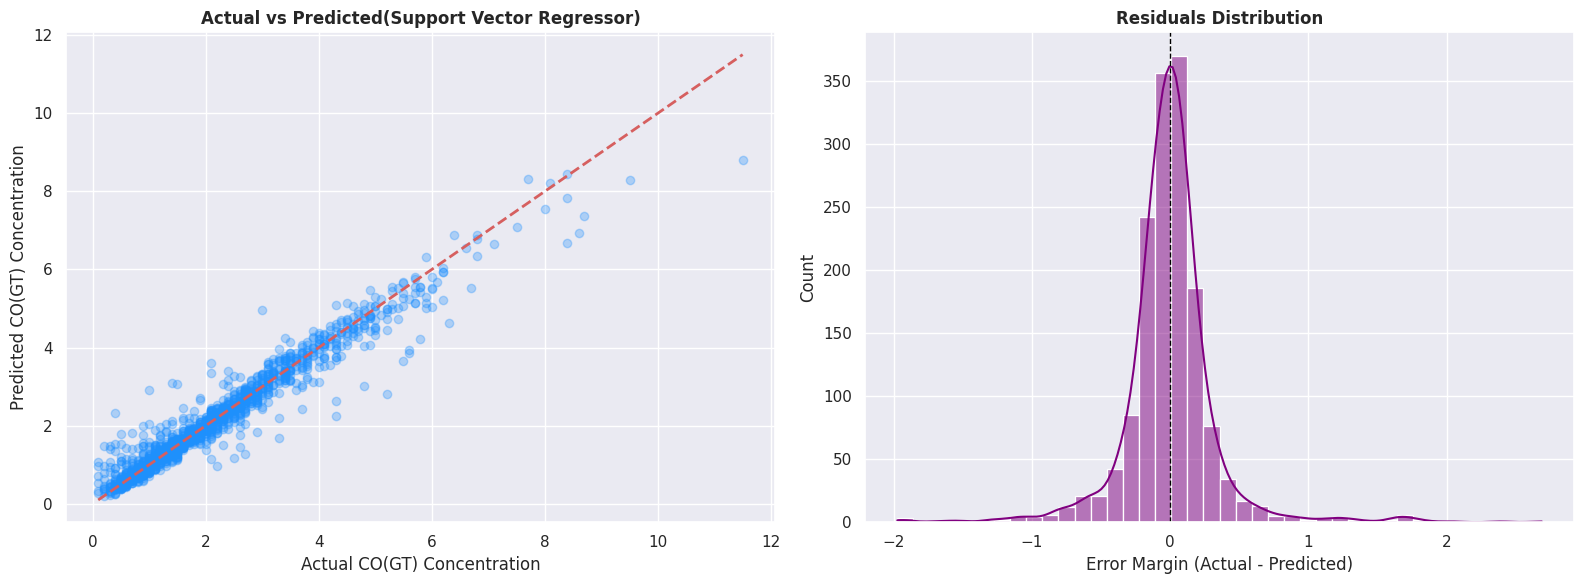

In [7]:
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

if best_model_name in ["Linear Regression", "Ridge Regression (L2)", "Support Vector Regressor"]:
  final_preds = best_model.predict(X_test_scaled)
else:
  final_preds = best_model.predict(X_test)

axes[0].scatter(y_test, final_preds, alpha = 0.3, color = "dodgerblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw = 2)
axes[0].set_xlabel("Actual CO(GT) Concentration")
axes[0].set_ylabel("Predicted CO(GT) Concentration")
axes[0].set_title(f"Actual vs Predicted({best_model_name})", fontweight = "bold")

residuals = y_test - final_preds
sns.histplot(residuals, kde = True, color = 'purple', bins = 40, ax = axes[1])
axes[1].axvline(0, color = "black", linestyle = "--", lw = 1)
axes[1].set_xlabel("Error Margin (Actual - Predicted)")
axes[1].set_title("Residuals Distribution", fontweight = "bold")

plt.tight_layout()
plt.show()

In [8]:
def predict_air_quality(new_data_dict, model, model_name, feature_list, scaler_obj = None):
  """
  Takes a dictionary of new sensor readings, formats it,
  applies necessary scaling, and outputs the predicted Carbon Monoxide level.
  """
  input_df = pd.DataFrame([new_data_dict])

  for col in feature_list:
    if col not in input_df.columns:
      input_df[col] = X_train[col].median()

  input_df = input_df[feature_list]

  if model_name in ["Linear Regression", "Ridge Regression (L2)", "Support Vector Regressor"]:
    input_data = scaler_obj.transform(input_df)
  else:
    input_data = input_df

  prediction = model.predict(input_data)[0]

  print("\n" + "=" * 60)
  print(f"INFERENCE PRED: {prediction:.2f} mg/m³ CO(GT)")
  print("=" * 60)
  return prediction

print("\n🔮 Testing Inference Pipeline...")
sample_reading = {
    'PT08.S1(CO)': 1360.0,
    'C6H6(GT)': 11.9,
    'PT08.S2(NMHC)': 1046.0,
    'NOx(GT)': 166.0,
    'T': 13.6,
    'RH': 48.9,
    'AH': 0.75,
    'DayOfWeek': 2,
    'Is_Weekend': 0,
    'Month': 3,
    'Hour_sin': 0.85,
    'Hour_cos': -0.52
}

predict_air_quality(sample_reading, best_model, best_model_name, features, scaler)



🔮 Testing Inference Pipeline...

INFERENCE PRED: 2.29 mg/m³ CO(GT)


np.float64(2.285553841887417)

In [9]:
import joblib
import os

# Create a local directory to store the model artifacts
save_dir = "saved_model_artifacts"
os.makedirs(save_dir, exist_ok=True)

# Calculate medians for fallback imputation during inference
feature_medians = X_train.median().to_dict()

# Save ALL models, the metrics, and preprocessing tools
joblib.dump(models, f"{save_dir}/all_models.pkl")
joblib.dump(results, f"{save_dir}/model_metrics.pkl")
joblib.dump(scaler, f"{save_dir}/scaler.pkl")
joblib.dump(features, f"{save_dir}/features.pkl")
joblib.dump(feature_medians, f"{save_dir}/medians.pkl")

print(f"✅ Successfully saved all models and comparative metrics to '{save_dir}/'!")

✅ Successfully saved all models and comparative metrics to 'saved_model_artifacts/'!


In [10]:
!zip -r saved_model_artifacts.zip saved_model_artifacts/

  adding: saved_model_artifacts/ (stored 0%)
  adding: saved_model_artifacts/all_models.pkl (deflated 81%)
  adding: saved_model_artifacts/scaler.pkl (deflated 28%)
  adding: saved_model_artifacts/medians.pkl (deflated 34%)
  adding: saved_model_artifacts/features.pkl (deflated 28%)
  adding: saved_model_artifacts/model_metrics.pkl (deflated 23%)
